# EMG TRIAL INITIATION SIMULATOR


In [4]:
# Phase 0: Imports and Constants (from helpers.py)
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
from open_ephys.analysis import Session
import scipy.stats as stats
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from helpers import *

# Override default protocol for this notebook
DEFAULT_PROTOCOL = PROTOCOL_ONLINE

print("Phase 0: imports and constants loaded. Default protocol:", DEFAULT_PROTOCOL)

Phase 0: imports and constants loaded. Default protocol: Online Filtering


# 1. Selecting and Exploring a Recording Session

Open Ephys organizes experiments into “sessions,” each with one or more Record Nodes.
Here we select which node to analyze and define which session directory to load.

### Function: Scanning Experiment Structure

We’ll define a helper function to automatically list all experiments and recordings inside a session directory.

In [5]:
# scan_experiment_structure() is now imported from helpers.py

# 2. Loading the Session Data

Now let’s point Python to a specific Open Ephys session directory and create a Session object.

In [6]:
# ==== Load Session ====
#directory = 'HR-08-TEST_TTL_OFF_POLARITY_CORRECT_2026-03-24_15-28-47_004'
#directory = 'HR-08-TEST_TTL_OFF_POLARITY_FLIPPED_2026-03-24_14-55-08_002'
directory = 'HRPILOT-18_EMG_CHARACTERIZATION_2026-05-12_13-15-07_001'

session = Session(directory)
print('✅ Pass Initial Test, Moving on to Loading Session...\n')

✅ Pass Initial Test, Moving on to Loading Session...



### Scanning the Session's Structure


In [7]:
record_node_name = "Record Node 106" if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else "Record Node 111"
record_node_index = 0 if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else 1
structure = scan_experiment_structure(directory, record_node_name)

# Flatten all experiment-recording pairs
flat_recordings = []
for exp_name, rec_list in structure.items():
    for rec in rec_list:
        flat_recordings.append((exp_name, rec))

print(f"Found {len(flat_recordings)} recordings across {len(structure)} experiments.")

Found 1 recordings across 1 experiments.


In [ ]:

# Phase 1: Recording selection and metadata loading
from ipywidgets import Button, Output, Dropdown

# Make options from flat_recordings if available
try:
    rec_options = [f"{i}: {e}/{r}" for i,(e,r) in enumerate(flat_recordings)]
except Exception:
    rec_options = []

recording_dropdown = Dropdown(options=rec_options, description='Recording:')
load_recording_button = Button(description='Open Recording', button_style='primary')
rec_output = Output()


def on_open_recording(b):
    with rec_output:
        clear_output()
        if not recording_dropdown.options:
            print("No recordings discovered. Use the 'Load Session' button in Phase 0 and select a record node.")
            return
        sel = recording_dropdown.value
        idx = int(str(sel).split(':',1)[0])
        try:
            # Try to fetch recording from Session object
            recording = session.recordnodes[record_node_index].recordings[idx]
            globals()['recording'] = recording
            print("Loaded recording:", recording)
            directory_str = recording.directory
            globals()['directory_str'] = directory_str

            parts = directory_str.split(os.sep)
            record_node_name = parts[-3]
            experiment_name  = parts[-2]
            recording_name   = parts[-1]
            globals()['record_node_name'] = record_node_name
            globals()['experiment_name'] = experiment_name
            globals()['recording_name'] = recording_name

            # Extract continuous data and metadata
            stream = recording.continuous[0]
            metadata = stream.metadata
            globals()['sample_rate'] = metadata.sample_rate
            globals()['num_channels'] = metadata.num_channels
            globals()['channel_names'] = metadata.channel_names

            print(f"Sample rate: {metadata.sample_rate} Hz | Channels: {metadata.num_channels} | Names: {metadata.channel_names}")

            # Update BIN_SAMPLE_COUNT based on actual sample_rate
            global BIN_SAMPLE_COUNT
            BIN_SAMPLE_COUNT = int((metadata.sample_rate / 1000) * BIN_DURATION_MS)
            print(f"BIN_SAMPLE_COUNT set to {BIN_SAMPLE_COUNT} samples")

            # Preload full data (be careful on large datasets)
            timestamps = stream.timestamps
            n_timestamps = timestamps.shape[0]
            data = stream.get_samples(start_sample_index=0, end_sample_index=n_timestamps)
            globals()['timestamps'] = timestamps
            globals()['data'] = data
            print("Data shape:", data.shape)

        except Exception as e:
            print("Error loading recording:", e)

load_recording_button.on_click(on_open_recording)

display(recording_dropdown, load_recording_button, rec_output)


Dropdown(description='Recording:', options=('0: experiment1/recording1',), value='0: experiment1/recording1')

Button(button_style='primary', description='Open Recording', style=ButtonStyle())

Output()

Using Online Filtering: assuming channel 3 is prefiltered differential EMG


C:\Users\dal866445\AppData\Local\Temp\ipykernel_17156\649266203.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\dal866445\Documents\Github\open-ephys-python-tools\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


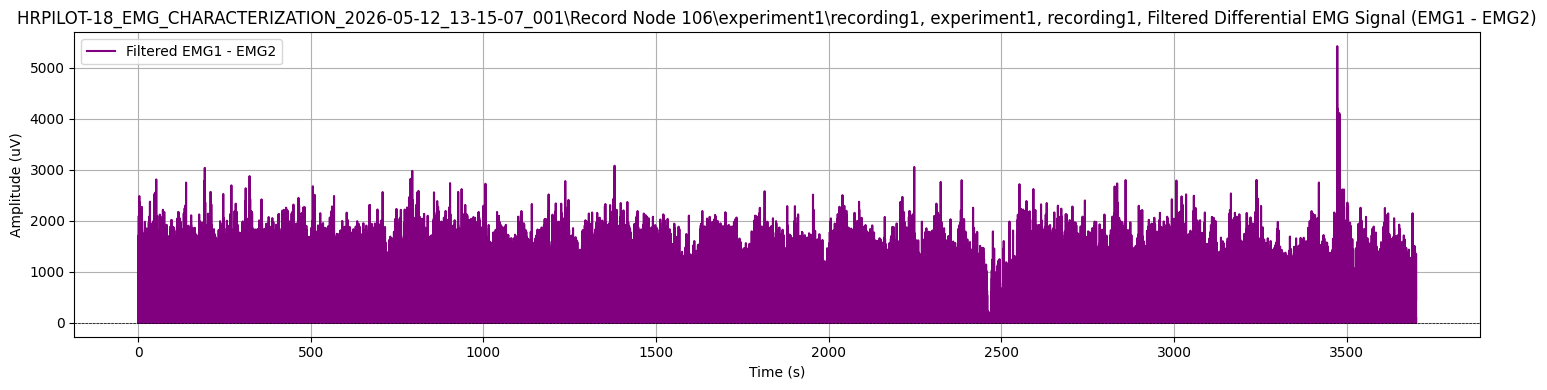

In [16]:

# Phase 1: EMG processing and full-trace plotting (using helpers.process_emg_signal)

try:
    timestamps
    data
except NameError:
    print("No recording data loaded. Please open a recording first.")
else:
    sample_rate = globals().get('sample_rate', SAMPLE_RATE_HINT)
    differential_filt, differential_emg = process_emg_signal(data, record_node_name, sample_rate)

    plt.figure(figsize=(15, 4))
    plt.plot(timestamps, differential_emg, label="Filtered EMG1 - EMG2", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"{directory_str}, {experiment_name}, {recording_name}, Filtered Differential EMG Signal (EMG1 - EMG2)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (uV)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [17]:
# Phase 1: Segment navigation UI (view long recordings in short windows)
segment_duration = 10  # seconds
try:
    total_time = timestamps[-1] - timestamps[0]
    num_segments = int(np.ceil(total_time / segment_duration))
    current_segment = 0

    from ipywidgets import Button, VBox
    output_segment = Output()

    def plot_segment(segment_idx):
        start_time = timestamps[0] + segment_idx * segment_duration
        end_time = min(start_time + segment_duration, timestamps[-1])
        mask = (timestamps >= start_time) & (timestamps < end_time)
        plt.figure(figsize=(15, 4))
        plt.plot(timestamps[mask] - start_time, differential_emg[mask], label="Filtered EMG", color='purple')
        # show blanking regions if available
        try:
            if 'blank_mask' in globals():
                # overlay shaded regions where blank_mask is False
                blank_mask_seg = ~blank_mask[mask]
                if blank_mask_seg.any():
                    # find contiguous runs and shade
                    idxs = np.where(mask)[0]
                    runs = []
                    run_start = None
                    for local_i, global_idx in enumerate(idxs):
                        if blank_mask_seg[local_i] and run_start is None:
                            run_start = timestamps[global_idx] - start_time
                        if (not blank_mask_seg[local_i] or local_i == len(idxs)-1) and run_start is not None:
                            run_end = timestamps[global_idx] - start_time
                            runs.append((run_start, run_end))
                            run_start = None
                    for s,e in runs:
                        plt.axvspan(s, e, color='red', alpha=0.25)
        except Exception:
            pass

        plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
        # compute and show blank fraction in this segment if available
        seg_blank_frac = 0.0
        if 'blank_mask' in globals():
            try:
                seg_mask = blank_mask[mask]
                seg_blank_frac = 1.0 - (np.sum(seg_mask) / float(seg_mask.size)) if seg_mask.size>0 else 0.0
            except Exception:
                seg_blank_frac = 0.0
        plt.title(f"{directory_str}, {experiment_name}, {recording_name}, Segment {segment_idx+1}/{num_segments} | Time: {start_time:.1f}-{end_time:.1f}s | blank={seg_blank_frac:.2%}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude (μV)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def on_next(b):
        global current_segment
        if current_segment < num_segments - 1:
            current_segment += 1
            with output_segment:
                output_segment.clear_output(wait=True)
                plot_segment(current_segment)

    def on_prev(b):
        global current_segment
        if current_segment > 0:
            current_segment -= 1
            with output_segment:
                output_segment.clear_output(wait=True)
                plot_segment(current_segment)

    next_button = Button(description="Next")
    prev_button = Button(description="Previous")
    next_button.on_click(on_next)
    prev_button.on_click(on_prev)

    # Initial plot
    with output_segment:
        plot_segment(current_segment)

    display(VBox([prev_button, next_button, output_segment]))

except Exception as e:
    print("Could not set up segment navigation:", e)


In [18]:

# Phase 1: Load MessageCenter events using helpers
try:
    message_entries = load_message_center_events(
        directory_str, record_node_name, experiment_name, recording_name)
    for t, txt in message_entries[:20]:
        print(f"[Time: {t:.6f} s] Message: {txt}")
except Exception as e:
    print("MessageCenter load error:", e)
    message_entries = []

Loaded 0 MessageCenter entries from HRPILOT-18_EMG_CHARACTERIZATION_2026-05-12_13-15-07_001\Record Node 106\experiment1\recording1\events\MessageCenter


## Background EMG Distribution Histogram

This cell builds a histogram of the background EMG signal to help guide threshold selection before running the simulation.

The `differential_emg` signal is divided into **`BIN_DURATION_MS`-ms bins** (matching the binning used by the trial initiation system), and the mean absolute amplitude of each bin is computed. The resulting distribution is plotted with:

- **Red dashed lines** — current `TRIAL_INIT_MIN_UV` / `TRIAL_INIT_MAX_UV` thresholds (visible only after running Phase 5a)
- **Orange dotted lines** — Q1 and Q3
- **Purple dash-dot line** — median

Use this plot to set appropriate initiation thresholds in Phase 5a. Re-run this cell after updating thresholds to see where they fall relative to the distribution.

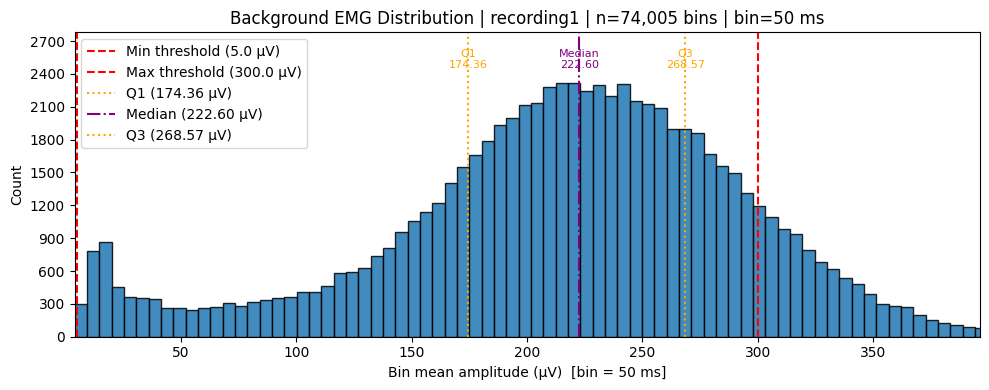

Background EMG bin-mean stats: n=74,005 | min=3.760 | Q1=174.360 | median=222.603 | Q3=268.573 | max=538.737 μV | std=79.33 μV


In [19]:
# Background EMG Distribution Histogram
# Divides the full differential_emg signal into BIN_DURATION_MS bins and plots
# the distribution of bin means — use this to guide TRIAL_INIT_MIN_UV / TRIAL_INIT_MAX_UV.
from matplotlib.ticker import MaxNLocator

try:
    differential_emg
    timestamps
    sample_rate
except NameError:
    print("No EMG data loaded. Please run the recording loading cells first.")
else:
    _bin_size = int((sample_rate / 1000) * BIN_DURATION_MS)
    _n_bins = len(differential_emg) // _bin_size
    _trimmed = differential_emg[:_n_bins * _bin_size]
    _bin_means = np.abs(_trimmed.reshape(_n_bins, _bin_size)).mean(axis=1)

    # Compute stats
    _mn  = float(np.min(_bin_means))
    _mx  = float(np.max(_bin_means))
    _n   = int(_bin_means.size)
    _std = float(np.std(_bin_means))
    _q25, _q50, _q75 = np.percentile(_bin_means, [25, 50, 75])
    _q1  = float(np.quantile(_bin_means, 0.01)) if _n > 1 else _mn
    _step = float(_q1 - _mn)
    if _step <= 0:
        _step = (_mx - _mn) / 100.0 if (_mx - _mn) > 0 else max(0.1, abs(_mx) * 0.01 if _mx != 0 else 0.1)

    # Build histogram bins (1 % step-size style, min 100 bins)
    _edges = np.arange(_mn - 0.5 * _step, _mx + 1.5 * _step, _step)
    if _edges.size < 2:
        _edges = np.linspace(_mn - 0.5, _mx + 0.5, 101)
    _hist_vals, _hist_edges = np.histogram(_bin_means, bins=_edges)
    if _hist_vals.size < 100:
        _hist_vals, _hist_edges = np.histogram(_bin_means, bins=100, range=(_mn, _mx))

    # Clip x-axis to 1st–99th percentile so outliers don't squash the view
    _p01 = float(np.percentile(_bin_means, 1))
    _p99 = float(np.percentile(_bin_means, 99))
    _pad = (_p99 - _p01) * 0.05
    _xlim_lo = max(_mn, _p01 - _pad)
    _xlim_hi = _p99 + _pad

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    _centers = (_hist_edges[:-1] + _hist_edges[1:]) / 2.0
    _widths  = _hist_edges[1:] - _hist_edges[:-1]
    ax.bar(_centers, _hist_vals, width=_widths, align='center',
           color='C0', edgecolor='k', alpha=0.85)

    ax.set_xlabel(f'Bin mean amplitude (μV)  [bin = {BIN_DURATION_MS} ms]')
    ax.set_ylabel('Count')
    ax.set_title(
        f'Background EMG Distribution | {recording_name} | '
        f'n={_n:,} bins | bin={BIN_DURATION_MS} ms'
    )
    ax.set_xlim(_xlim_lo, _xlim_hi)

    # Initiation threshold lines (only if already defined)
    try:
        ax.axvline(TRIAL_INIT_MIN_UV, color='red', linestyle='--', linewidth=1.5,
                   label=f'Min threshold ({TRIAL_INIT_MIN_UV} μV)')
        ax.axvline(TRIAL_INIT_MAX_UV, color='red', linestyle='--', linewidth=1.5,
                   label=f'Max threshold ({TRIAL_INIT_MAX_UV} μV)')
    except NameError:
        pass  # thresholds defined later in Phase 5a — run that cell first, then re-run this one

    # Quartile lines and labels
    _ymax  = int(max(_hist_vals)) if _hist_vals.size > 0 else 1
    _y_txt = _ymax * 1.05
    ax.axvline(_q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q1 ({_q25:.2f} μV)')
    ax.axvline(_q50, color='purple', linestyle='-.', linewidth=1.5, label=f'Median ({_q50:.2f} μV)')
    ax.axvline(_q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q3 ({_q75:.2f} μV)')
    ax.text(_q25, _y_txt, f'Q1\n{_q25:.2f}', color='orange', ha='center', va='bottom', fontsize=8)
    ax.text(_q50, _y_txt, f'Median\n{_q50:.2f}', color='purple', ha='center', va='bottom', fontsize=8)
    ax.text(_q75, _y_txt, f'Q3\n{_q75:.2f}', color='orange', ha='center', va='bottom', fontsize=8)

    ax.set_ylim(0, _ymax * 1.2 + 1)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"Background EMG bin-mean stats: "
        f"n={_n:,} | min={_mn:.3f} | Q1={_q25:.3f} | "
        f"median={_q50:.3f} | Q3={_q75:.3f} | max={_mx:.3f} μV | std={_std:.2f} μV"
    )

## Phase 5a: Configuration and Helper Classes

This cell defines the simulation parameters and implements the core `TrialInitiationData` class that replicates the logic from `mh_recruitment_curve_stage.py`.

In [20]:
# Phase 5a: Simulation Configuration
# SimulatedTrial, TrialInitiationData, round_to_nearest_multiple are imported from helpers.py





# Override thresholds for this session (narrow band around measured baseline)
#TRIAL_INIT_MIN_UV = _q50 - _std*0.10
#TRIAL_INIT_MAX_UV = _q50 + _std*0.10
#TRIAL_INIT_MIN_UV = 30
#TRIAL_INIT_MAX_UV = 75.94

MINIMUM_INTERTRIAL_INTERVAL_MS = 3000


print("=" * 70)
print("PHASE 5 SIMULATION CONFIGURATION")
print("=" * 70)
print(f"Initiation Thresholds: {TRIAL_INIT_MIN_UV:.1f} - {TRIAL_INIT_MAX_UV:.1f} uV")
print(f"Monitoring Window: {TRIAL_INIT_MIN_MS} - {TRIAL_INIT_MAX_MS} ms")
print(f"Bin Duration: {BIN_DURATION_MS} ms")
print(f"Min Inter-Trial Interval: {MINIMUM_INTERTRIAL_INTERVAL_MS} ms")
print(f"Simulation Block Size: {SIMULATION_BLOCK_SIZE} samples")
print(f"Random Seed: {SIMULATION_RANDOM_SEED}")
print("=" * 70)

PHASE 5 SIMULATION CONFIGURATION
Initiation Thresholds: 5.0 - 300.0 uV
Monitoring Window: 2200 - 2700 ms
Bin Duration: 50 ms
Min Inter-Trial Interval: 3000 ms
Simulation Block Size: 50 samples
Random Seed: 42


## Phase 5b: Main Simulation Engine — State Machine Implementation

This cell contains the core simulation loop that processes the recorded EMG data using a state machine to simulate real-time trial initialization.

In [21]:
# Phase 5b: Run Trial Initiation Simulation
# run_trial_initiation_simulation() is imported from helpers.py

print("Preparing to run simulation...")

try:
    assert 'differential_emg' in globals(), "differential_emg not found! Run Phase 1 first."
    assert 'timestamps' in globals(), "timestamps not found! Run Phase 1 first."
    assert 'sample_rate' in globals(), "sample_rate not found! Run Phase 1 first."

    print(f"EMG signal: {len(differential_emg):,} samples | Sample rate: {sample_rate} Hz")

    simulated_trials, sim_statistics = run_trial_initiation_simulation(
        emg_signal=differential_emg,
        timestamps=timestamps,
        sample_rate=sample_rate,
        min_init_threshold=TRIAL_INIT_MIN_UV,
        max_init_threshold=TRIAL_INIT_MAX_UV,
        block_size=SIMULATION_BLOCK_SIZE,
        min_inter_trial_ms=MINIMUM_INTERTRIAL_INTERVAL_MS,
        verbose=True,
        max_trials=None,
    )

    # Store results in global scope for downstream analysis
    globals()['simulated_trials'] = simulated_trials
    globals()['sim_statistics'] = sim_statistics

    globals()['successful_trials'] = [t for t in simulated_trials
                                       if t.grand_mean_uv >= TRIAL_INIT_MIN_UV
                                       and t.grand_mean_uv <= TRIAL_INIT_MAX_UV]
    globals()['shifted_trials'] = [t for t in simulated_trials if t.needed_shifting]

    # Monitoring window duration storage
    globals()['all_monitoring_windows_ms'] = [t.monitoring_duration_ms for t in simulated_trials]
    globals()['successful_monitoring_windows_ms'] = [t.monitoring_duration_ms for t in simulated_trials
                                                      if not t.needed_shifting]
    # Unsuccessful = total search duration (monitoring_duration + shifts * 50ms) for shifted trials
    globals()['unsuccessful_monitoring_windows_ms'] = [t.total_search_duration_ms for t in simulated_trials
                                                        if t.needed_shifting]

    # Per-trial detail data
    globals()['trial_window_data'] = [
        {
            'trial_number': t.trial_number,
            'monitoring_window_ms': t.monitoring_duration_ms,
            'grand_mean_uv': t.grand_mean_uv,
            'start_time': t.start_time,
            'needed_shifting': t.needed_shifting,
            'num_shifts': t.num_shifts,
            'total_search_duration_ms': t.total_search_duration_ms,
            'outcome': 'immediate_success' if not t.needed_shifting else f'shifted_success ({t.num_shifts} shifts)'
        }
        for t in simulated_trials
    ]

    print("=" * 80)
    print("RESULTS STORED")
    print("=" * 80)
    print(f"  simulated_trials: {len(simulated_trials)}")
    print(f"  successful_trials: {len(globals()['successful_trials'])}")
    print(f"  shifted_trials: {len(globals()['shifted_trials'])}")
    print(f"  successful_monitoring_windows_ms: {len(globals()['successful_monitoring_windows_ms'])} values")
    print(f"  unsuccessful_monitoring_windows_ms: {len(globals()['unsuccessful_monitoring_windows_ms'])} values")
    print(f"  trial_window_data: {len(globals()['trial_window_data'])} entries")
    print("=" * 80)

    # ================================================================
    # Trial EMG Window Browser — navigate each trial's monitoring window
    # ================================================================
    from ipywidgets import Button, VBox, HBox, Output, Label

    bin_sample_count = int((sample_rate / 1000) * BIN_DURATION_MS)
    current_trial_idx = 0
    trial_output = Output()
    trial_label = Label(value=f"Trial 1 / {len(simulated_trials)}")

    def plot_trial_window(trial_idx):
        trial = simulated_trials[trial_idx]
        monitoring_samples = int((sample_rate / 1000) * trial.monitoring_duration_ms)

        # The accepted window starts after any shifts applied
        window_start = trial.start_sample_idx + trial.num_shifts * bin_sample_count
        window_end = window_start + monitoring_samples

        # Clamp to signal bounds
        window_start = max(0, window_start)
        window_end = min(len(differential_emg), window_end)

        emg_segment = differential_emg[window_start:window_end]
        ts_segment = timestamps[window_start:window_end]

        # Time axis in ms relative to window start
        if len(ts_segment) > 0:
            time_ms = (ts_segment - ts_segment[0]) * 1000
        else:
            time_ms = np.array([])

        fig, ax = plt.subplots(figsize=(15, 4))

        # EMG trace
        ax.plot(time_ms, emg_segment, color='purple', linewidth=0.8, label='Rectified EMG')

        # Bin means as horizontal bars spanning each bin
        num_bins = len(emg_segment) // bin_sample_count
        if num_bins > 0:
            for b in range(num_bins):
                b_start = b * bin_sample_count
                b_end = b_start + bin_sample_count
                bin_mean = np.mean(emg_segment[b_start:b_end])
                bin_t_start = time_ms[b_start] if b_start < len(time_ms) else time_ms[-1]
                bin_t_end = time_ms[min(b_end - 1, len(time_ms) - 1)]
                ax.hlines(bin_mean, bin_t_start, bin_t_end, colors='orange',
                          linewidth=2.5, alpha=0.8,
                          label='Bin mean' if b == 0 else None)

        # Grand mean
        ax.axhline(trial.grand_mean_uv, color='green', linestyle='--', linewidth=2,
                    label=f'Grand mean = {trial.grand_mean_uv:.2f} uV')

        # Thresholds
        ax.axhline(TRIAL_INIT_MIN_UV, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                    label=f'Min threshold = {TRIAL_INIT_MIN_UV:.1f} uV')
        ax.axhline(TRIAL_INIT_MAX_UV, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                    label=f'Max threshold = {TRIAL_INIT_MAX_UV:.1f} uV')
        ax.axhspan(TRIAL_INIT_MIN_UV, TRIAL_INIT_MAX_UV, color='green', alpha=0.05)

        # Title with trial metadata
        shift_info = (f" | {trial.num_shifts} shifts ({trial.total_search_duration_ms:.0f} ms search)"
                      if trial.needed_shifting else " | immediate")
        ax.set_title(
            f"Trial #{trial.trial_number} / {len(simulated_trials)} | "
            f"Grand Mean: {trial.grand_mean_uv:.2f} uV | "
            f"Window: {trial.monitoring_duration_ms} ms | "
            f"Time: {trial.start_time:.2f} s"
            f"{shift_info}"
        )
        ax.set_xlabel("Time within monitoring window (ms)")
        ax.set_ylabel("Amplitude (uV)")
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def on_next_trial(b):
        global current_trial_idx
        if current_trial_idx < len(simulated_trials) - 1:
            current_trial_idx += 1
            trial_label.value = f"Trial {current_trial_idx + 1} / {len(simulated_trials)}"
            with trial_output:
                trial_output.clear_output(wait=True)
                plot_trial_window(current_trial_idx)

    def on_prev_trial(b):
        global current_trial_idx
        if current_trial_idx > 0:
            current_trial_idx -= 1
            trial_label.value = f"Trial {current_trial_idx + 1} / {len(simulated_trials)}"
            with trial_output:
                trial_output.clear_output(wait=True)
                plot_trial_window(current_trial_idx)

    prev_trial_btn = Button(description="Previous Trial")
    next_trial_btn = Button(description="Next Trial")
    prev_trial_btn.on_click(on_prev_trial)
    next_trial_btn.on_click(on_next_trial)

    # Initial plot
    with trial_output:
        plot_trial_window(current_trial_idx)

    display(VBox([HBox([prev_trial_btn, next_trial_btn, trial_label]), trial_output]))

except AssertionError as e:
    print(f"Error: {e}")
except Exception as e:
    print(f"Unexpected error: {e}")
    import traceback
    traceback.print_exc()

Preparing to run simulation...
EMG signal: 18,501,405 samples | Sample rate: 5000.0 Hz
STARTING TRIAL INITIATION SIMULATION (with bin sliding)
Total samples: 18,501,405 | Duration: 3700.28s
Thresholds: 5.0 - 300.0 uV
Min ITI: 3000 ms | Block: 50 samples | Bin slide: 50 ms (250 samples)

[NOT_SETUP -> WAIT] Attempt #1 | Window: 2550 ms | Time: 0.65s
  [IMMEDIATE] Trial #1 | GM:260.47 uV | Window:2550 ms | Time:3.20s | ISI:6200 ms

[NOT_SETUP -> WAIT] Attempt #2 | Window: 2250 ms | Time: 3.21s
  [IMMEDIATE] Trial #2 | GM:184.54 uV | Window:2250 ms | Time:8.44s | ISI:5240 ms

[NOT_SETUP -> WAIT] Attempt #3 | Window: 2200 ms | Time: 8.45s
  [IMMEDIATE] Trial #3 | GM:263.99 uV | Window:2200 ms | Time:13.64s | ISI:5200 ms

[NOT_SETUP -> WAIT] Attempt #4 | Window: 2600 ms | Time: 13.65s
  [IMMEDIATE] Trial #4 | GM:266.27 uV | Window:2600 ms | Time:19.23s | ISI:5590 ms

[NOT_SETUP -> WAIT] Attempt #5 | Window: 2350 ms | Time: 19.24s
  [IMMEDIATE] Trial #5 | GM:214.02 uV | Window:2350 ms | Time

In [22]:
total_successful_trial_time = sum(successful_monitoring_windows_ms)
print(total_successful_trial_time)

total_unsuccessful_trial_time = sum(unsuccessful_monitoring_windows_ms)
print(total_unsuccessful_trial_time)

print(total_successful_trial_time/total_unsuccessful_trial_time *100)

recording_duration_ms = (timestamps[-1] - timestamps[0]) * 1000
print(recording_duration_ms)

print(total_successful_trial_time/recording_duration_ms * 100) 


#Total amount of time that could have been stimulated, what percentage of that are we getting. 
#Total amount of time spent in intiation thresholds (without 10 s blankout)


1593350
90250.0
1765.4847645429363
3700280.7999999905
43.06024559001047


## Phase 5c: Results Analysis and Visualization

Now that the simulation is complete, let's analyze the results with comprehensive statistics and visualizations.

PHASE 5 SIMULATION RESULTS — DETAILED ANALYSIS

📊 SUMMARY STATISTICS
--------------------------------------------------------------------------------
Total Monitoring Attempts:     674
Successful Trial Initiations:  673
Success Rate:                  100.00%

Recording Duration:            3700.28 seconds
Total Samples Processed:       18,501,405
Simulation Time:               19.41 seconds
Processing Speed:              953,324 samples/sec

Inter-Trial Interval Stats (ms):
  Mean:                        5,496.9 ms
  Median:                      5,450.0 ms
  Std Dev:                     384.2 ms
  Min:                         5,190.0 ms
  Max:                         9,309.8 ms

Grand Mean EMG Stats (μV):
  Mean:                        214.78 μV
  Median:                      219.42 μV
  Std Dev:                     53.20 μV
  Min:                         12.11 μV
  Max:                         299.86 μV

Monitoring Duration Stats (ms):
  Mean:                        2447.3 ms
  Min:  

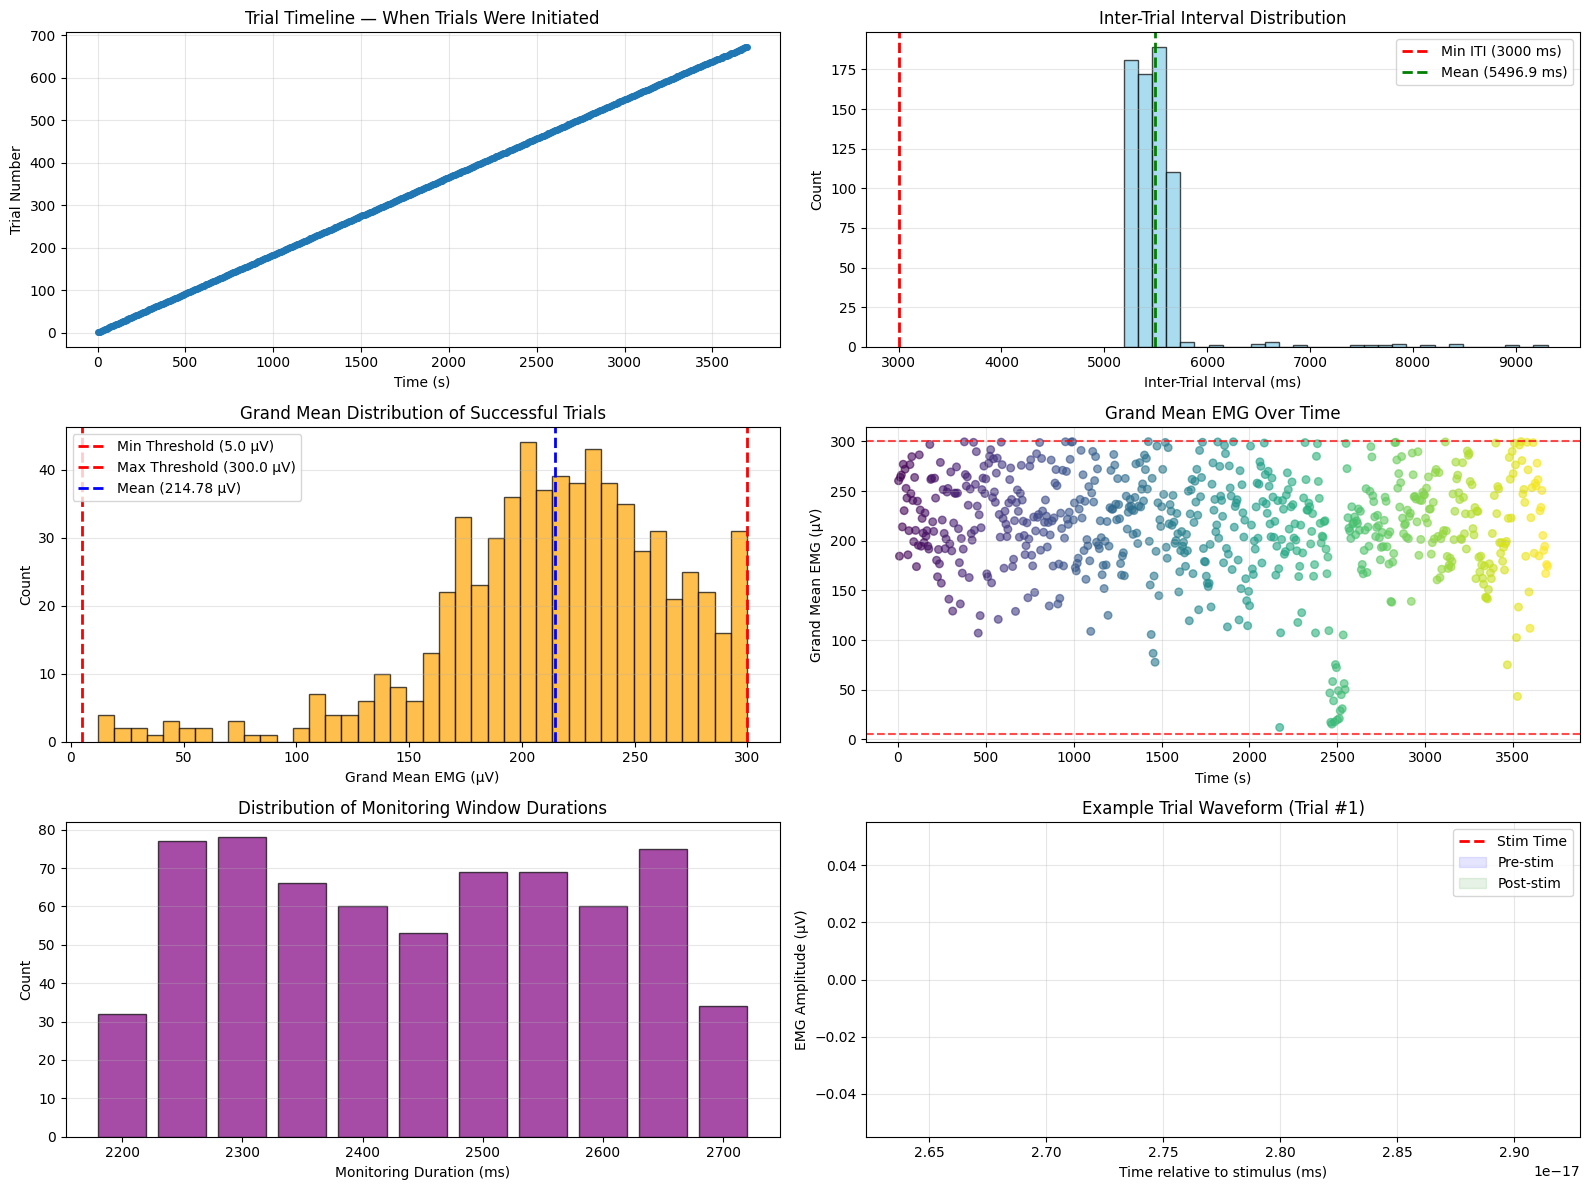

 Visualizations generated successfully.

⏱️  TRIAL RATE ANALYSIS
--------------------------------------------------------------------------------
Recording Duration:            1.028 hours
Total Trials:                  673
Trials per Hour:               654.8
Target (if applicable):        150 trials/hour (from recruitment curve stage)
--------------------------------------------------------------------------------

ANALYSIS COMPLETE


In [23]:
# Phase 5c: Detailed Results Analysis and Visualization

if 'simulated_trials' not in globals() or 'sim_statistics' not in globals():
    print("❌ No simulation results found. Please run Phase 5b first.")
else:
    print("=" * 80)
    print("PHASE 5 SIMULATION RESULTS — DETAILED ANALYSIS")
    print("=" * 80)
    print()
    
    # ================================================================
    # SECTION 1: Summary Statistics
    # ================================================================
    print("📊 SUMMARY STATISTICS")
    print("-" * 80)
    print(f"Total Monitoring Attempts:     {sim_statistics['total_monitoring_attempts']:,}")
    print(f"Successful Trial Initiations:  {sim_statistics['successful_trials']:,}")
    print(f"Success Rate:                  {sim_statistics['success_rate_pct']:.2f}%")
    print()
    print(f"Recording Duration:            {timestamps[-1] - timestamps[0]:.2f} seconds")
    print(f"Total Samples Processed:       {sim_statistics['total_samples_processed']:,}")
    print(f"Simulation Time:               {sim_statistics['elapsed_time_seconds']:.2f} seconds")
    print(f"Processing Speed:              {sim_statistics['processing_speed_samples_per_sec']:,.0f} samples/sec")
    print()
    
    if len(simulated_trials) > 1:
        # Trial timing statistics
        inter_trial_intervals = sim_statistics['inter_trial_intervals_ms']
        print(f"Inter-Trial Interval Stats (ms):")
        print(f"  Mean:                        {np.mean(inter_trial_intervals):,.1f} ms")
        print(f"  Median:                      {np.median(inter_trial_intervals):,.1f} ms")
        print(f"  Std Dev:                     {np.std(inter_trial_intervals):,.1f} ms")
        print(f"  Min:                         {np.min(inter_trial_intervals):,.1f} ms")
        print(f"  Max:                         {np.max(inter_trial_intervals):,.1f} ms")
        print()
        
        # Grand mean statistics
        grand_means = [t.grand_mean_uv for t in simulated_trials]
        print(f"Grand Mean EMG Stats (μV):")
        print(f"  Mean:                        {np.mean(grand_means):.2f} μV")
        print(f"  Median:                      {np.median(grand_means):.2f} μV")
        print(f"  Std Dev:                     {np.std(grand_means):.2f} μV")
        print(f"  Min:                         {np.min(grand_means):.2f} μV")
        print(f"  Max:                         {np.max(grand_means):.2f} μV")
        print()
        
        # Monitoring duration statistics
        mon_durations = [t.monitoring_duration_ms for t in simulated_trials]
        print(f"Monitoring Duration Stats (ms):")
        print(f"  Mean:                        {np.mean(mon_durations):.1f} ms")
        print(f"  Min:                         {np.min(mon_durations):.1f} ms")
        print(f"  Max:                         {np.max(mon_durations):.1f} ms")
        print()
    
    print("-" * 80)
    print()
    
    # ================================================================
    # SECTION 2: First Few Trials Detail
    # ================================================================
    print("🔍 FIRST 10 TRIALS (Detailed View)")
    print("-" * 80)
    print(f"{'#':<5} {'Time (s)':<12} {'Grand Mean':<15} {'Monitor (ms)':<15} {'ISI (ms)':<12}")
    print("-" * 80)
    
    for i, trial in enumerate(simulated_trials[:10]):
        isi_str = f"{trial.time_since_last_trial_ms:.1f}" if trial.time_since_last_trial_ms is not None else "N/A"
        print(f"{trial.trial_number:<5} "
              f"{trial.start_time:<12.2f} "
              f"{trial.grand_mean_uv:<15.2f} "
              f"{trial.monitoring_duration_ms:<15} "
              f"{isi_str:<12}")
    
    if len(simulated_trials) > 10:
        print(f"... and {len(simulated_trials) - 10} more trials")
    
    print("-" * 80)
    print()
    
    # ================================================================
    # SECTION 3: Visualization
    # ================================================================
    print("📈 GENERATING VISUALIZATIONS...")
    print()
    
    # Create a comprehensive multi-panel figure
    fig = plt.figure(figsize=(16, 12))
    
    # -------------------- Panel 1: Trial Timeline --------------------
    ax1 = plt.subplot(3, 2, 1)
    trial_times = [t.start_time for t in simulated_trials]
    trial_numbers = [t.trial_number for t in simulated_trials]
    ax1.plot(trial_times, trial_numbers, 'o-', markersize=4, linewidth=1)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Trial Number')
    ax1.set_title('Trial Timeline — When Trials Were Initiated')
    ax1.grid(True, alpha=0.3)
    
    # -------------------- Panel 2: Inter-Trial Intervals --------------------
    if len(simulated_trials) > 1:
        ax2 = plt.subplot(3, 2, 2)
        inter_trial_intervals = sim_statistics['inter_trial_intervals_ms']
        ax2.hist(inter_trial_intervals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        ax2.axvline(MINIMUM_INTERTRIAL_INTERVAL_MS, color='red', linestyle='--', 
                    linewidth=2, label=f'Min ITI ({MINIMUM_INTERTRIAL_INTERVAL_MS} ms)')
        ax2.axvline(np.mean(inter_trial_intervals), color='green', linestyle='--', 
                    linewidth=2, label=f'Mean ({np.mean(inter_trial_intervals):.1f} ms)')
        ax2.set_xlabel('Inter-Trial Interval (ms)')
        ax2.set_ylabel('Count')
        ax2.set_title('Inter-Trial Interval Distribution')
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
    
    # -------------------- Panel 3: Grand Mean Distribution --------------------
    ax3 = plt.subplot(3, 2, 3)
    grand_means = [t.grand_mean_uv for t in simulated_trials]
    ax3.hist(grand_means, bins=40, edgecolor='black', alpha=0.7, color='orange')
    ax3.axvline(TRIAL_INIT_MIN_UV, color='red', linestyle='--', 
                linewidth=2, label=f'Min Threshold ({TRIAL_INIT_MIN_UV} μV)')
    ax3.axvline(TRIAL_INIT_MAX_UV, color='red', linestyle='--', 
                linewidth=2, label=f'Max Threshold ({TRIAL_INIT_MAX_UV} μV)')
    ax3.axvline(np.mean(grand_means), color='blue', linestyle='--', 
                linewidth=2, label=f'Mean ({np.mean(grand_means):.2f} μV)')
    ax3.set_xlabel('Grand Mean EMG (μV)')
    ax3.set_ylabel('Count')
    ax3.set_title('Grand Mean Distribution of Successful Trials')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # -------------------- Panel 4: Grand Mean vs Time --------------------
    ax4 = plt.subplot(3, 2, 4)
    trial_times = [t.start_time for t in simulated_trials]
    grand_means = [t.grand_mean_uv for t in simulated_trials]
    ax4.scatter(trial_times, grand_means, alpha=0.6, s=30, c=range(len(trial_times)), cmap='viridis')
    ax4.axhline(TRIAL_INIT_MIN_UV, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax4.axhline(TRIAL_INIT_MAX_UV, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Grand Mean EMG (μV)')
    ax4.set_title('Grand Mean EMG Over Time')
    ax4.grid(True, alpha=0.3)
    
    # -------------------- Panel 5: Monitoring Duration Distribution --------------------
    ax5 = plt.subplot(3, 2, 5)
    mon_durations = [t.monitoring_duration_ms for t in simulated_trials]
    unique_durations, counts = np.unique(mon_durations, return_counts=True)
    ax5.bar(unique_durations, counts, width=40, edgecolor='black', alpha=0.7, color='purple')
    ax5.set_xlabel('Monitoring Duration (ms)')
    ax5.set_ylabel('Count')
    ax5.set_title('Distribution of Monitoring Window Durations')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # -------------------- Panel 6: Example Trial Waveform --------------------
    if len(simulated_trials) > 0:
        ax6 = plt.subplot(3, 2, 6)
        example_trial = simulated_trials[0]  # Show first trial
        
        # Combine pre and post stim data
        pre_data = example_trial.pre_stim_data
        post_data = example_trial.post_stim_data
        combined_data = np.concatenate([pre_data, post_data])
        
        # Create time axis (ms relative to stimulus)
        pre_duration_ms = len(pre_data) / sample_rate * 1000
        post_duration_ms = len(post_data) / sample_rate * 1000
        time_axis = np.linspace(-pre_duration_ms, post_duration_ms, len(combined_data))
        
        ax6.plot(time_axis, combined_data, color='black', linewidth=1)
        ax6.axvline(0, color='red', linestyle='--', linewidth=2, label='Stim Time')
        ax6.axvspan(-pre_duration_ms, 0, color='blue', alpha=0.1, label='Pre-stim')
        ax6.axvspan(0, post_duration_ms, color='green', alpha=0.1, label='Post-stim')
        ax6.set_xlabel('Time relative to stimulus (ms)')
        ax6.set_ylabel('EMG Amplitude (μV)')
        ax6.set_title(f'Example Trial Waveform (Trial #{example_trial.trial_number})')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(" Visualizations generated successfully.")
    print()
    
    # ================================================================
    # SECTION 4: Trial Rate Analysis
    # ================================================================
    if len(simulated_trials) > 0:
        recording_duration_hours = (timestamps[-1] - timestamps[0]) / 3600
        trials_per_hour = len(simulated_trials) / recording_duration_hours
        
        print("⏱️  TRIAL RATE ANALYSIS")
        print("-" * 80)
        print(f"Recording Duration:            {recording_duration_hours:.3f} hours")
        print(f"Total Trials:                  {len(simulated_trials)}")
        print(f"Trials per Hour:               {trials_per_hour:.1f}")
        print(f"Target (if applicable):        150 trials/hour (from recruitment curve stage)")
        print("-" * 80)
        print()
    
    print("=" * 80)
    print("ANALYSIS COMPLETE")
    print("=" * 80)

# Trial Initiation Simulation -- Comprehensive Overview

## Objective

This phase simulates the **real-time trial initialization process** used in the `Mh_recruitment_curve_stage.py` module but operates offline on recorded data. The goal is to:

1. **Replicate the state machine logic** that decides when to initiate a trial based on EMG activity
2. **Process the original (un-blanked) EMG signal** using a sliding window and binning approach
3. **Slide the monitoring window by 50ms bins** when the grand mean is outside thresholds, rather than discarding the attempt
4. **Track total search duration** (initial window + sliding time) for trials that required shifting
5. **Analyze success rates, shifting statistics, and timing**

---

## How the Trial Initialization System Works

The MH Recruitment Curve stage uses a state machine to determine optimal moments for electrical stimulation. This ensures stimuli are delivered during stable, quiet EMG periods rather than during muscle activation or noise.

### Key Design Principles

| Component | Description | Purpose |
|-----------|-------------|---------|
| **Sliding Monitoring Window** | Random duration 2200-2700 ms (rounded to 50 ms) | Prevents subject anticipation |
| **50 ms Bins** | Signal divided into 250-sample bins (at 5 kHz) | Smooths transient artifacts |
| **Grand Mean Threshold** | Mean of all bin means must fall within min/max bounds | Ensures baseline stability |
| **Bin Sliding** | When threshold not met, window slides forward by one 50ms bin at a time | Finds nearest quiet period instead of restarting |
| **Inter-Trial Interval** | Minimum 10 seconds between trials | Prevents overstimulation |
| **State Machine** | NOT_SETUP -> WAIT_FOR_INITIATION -> [SLIDE if needed] -> RECORD TRIAL | Structured trial flow |

---

## State Machine Architecture

```
+-------------------+
|    NOT_SETUP      | -> Pick random monitoring window (2200-2700 ms)
+--------+----------+   Initialize TrialInitiationData
         |
         v
+-------------------+
| WAIT_FOR_INIT     | -> Process EMG blocks, fill monitoring window
+--------+----------+
         |
         v (window full)
  +--------------+
  | Grand mean   |--Yes--> RECORD TRIAL as IMMEDIATE SUCCESS
  | in threshold?|         -> Return to NOT_SETUP
  +------+-------+
         | No
         v
  +-----------------+
  | SLIDE window    | -> Drop oldest 50ms bin, take new 50ms bin from recording
  | by one 50ms bin |    Re-compute grand mean
  +------+----------+
         |
         v
  +--------------+
  | Grand mean   |--No---> Loop back to SLIDE (repeat)
  | in threshold?|
  +------+-------+
         | Yes
         v
  RECORD TRIAL as SHIFTED SUCCESS
  (track num_shifts and total_search_duration_ms)
  -> Return to NOT_SETUP
```

### Key Behavioral Change: Bin Sliding Instead of Discarding

In the previous version, when the monitoring window was full but the grand mean was outside thresholds, the trial was recorded as **unsuccessful** and the system started a completely new monitoring attempt with a new random window duration.

**New behavior:** Instead of discarding the attempt, the system **slides the existing monitoring window forward by one 50ms bin** (drops the oldest 50ms of data from the front, takes the next 50ms of data from the recording at the end). The grand mean is re-evaluated after each slide. This repeats until the grand mean falls within thresholds.

This means:
- **Every trial eventually succeeds** (unless the end of the recording is reached)
- The `unsuccessful_monitoring_windows_ms` variable stores the **total search duration** for trials that needed sliding: `monitoring_duration_ms + (num_shifts * 50ms)`
- The `successful_monitoring_windows_ms` variable stores the monitoring duration for trials that met the threshold immediately (no sliding needed)

---

## Trial Initiation Algorithm (Pseudocode)

```python
# Setup phase (once per trial attempt)
monitoring_duration_ms = random(2200, 2700)  # randomized
monitoring_duration_ms = round_to_50ms(monitoring_duration_ms)
monitored_signal_buffer = []
bins = []
samples_needed = monitoring_duration_ms * sample_rate / 1000

# Phase 1: Fill the monitoring window
for each data_block in recording:
    append data_block to monitored_signal_buffer
    keep only most recent 'samples_needed' samples
    
    if buffer_full:
        # Bin the monitoring window
        for each 50ms bin:
            bins[i] = mean(monitored_signal_buffer[bin_range])
        grand_mean = mean(bins)
        
        if grand_mean in [min_threshold, max_threshold]:
            RECORD TRIAL as IMMEDIATE SUCCESS
            break
        else:
            # Phase 2: Bin sliding loop
            num_shifts = 0
            while grand_mean NOT in [min_threshold, max_threshold]:
                # Slide window by one 50ms bin
                take next 250 samples (50ms at 5kHz) from recording
                feed into TrialInitiationData (auto-trims oldest data)
                recompute bins and grand_mean
                num_shifts += 1
            
            total_search_duration = monitoring_duration_ms + num_shifts * 50
            RECORD TRIAL as SHIFTED SUCCESS
            store total_search_duration in unsuccessful_monitoring_windows_ms
```

---

## What This Phase Outputs

After running the simulation, you'll see:

- **Total trials**: How many trials were recorded
- **Immediate successes**: Trials that met threshold on first evaluation (no sliding)
- **Shifted successes**: Trials that required bin sliding to find threshold
- **Total shifts**: Sum of all bin slides across all trials
- **Mean shifts per shifted trial**: Average number of 50ms slides needed
- **Mean search duration (shifted)**: Average total time spent finding threshold for shifted trials
- **Inter-trial intervals**: Distribution of time between trials
- **Grand mean distribution**: Histogram of final grand means at trial initiation
- **Timeline visualization**: When trials occurred during the recording

### Key Variables Stored

| Variable | Description |
|----------|-------------|
| `simulated_trials` | All trials as SimulatedTrial objects |
| `successful_trials` | Trials that found threshold (all trials unless end-of-recording) |
| `shifted_trials` | Trials that needed bin sliding |
| `successful_monitoring_windows_ms` | Monitoring duration for immediate-success trials |
| `unsuccessful_monitoring_windows_ms` | Total search duration (monitoring + shifts*50ms) for shifted trials |
| `trial_window_data` | List of dicts with per-trial details including shift info |

---

## Implementation Notes

- **Uses original (un-blanked) EMG data**: This simulates the real-time system which doesn't know about future stimulus events
- **Block-based processing**: Data is processed in chunks to mimic real-time streaming (default: 50 samples ~10 ms at 5 kHz)
- **Bin sliding uses 50ms increments**: Each slide advances the window by exactly one bin (250 samples at 5 kHz), matching the bin size
- **Configurable thresholds**: You can adjust `TRIAL_INIT_MIN_UV` and `TRIAL_INIT_MAX_UV` (defined in Phase 0/5a) to explore different acceptance criteria
- **Reproducible**: Uses a seeded random number generator for consistent results
- **SimulatedTrial tracks shifts**: Each trial object stores `num_shifts`, `total_search_duration_ms`, and `needed_shifting` fields

---

## Required Data from Previous Phases

This phase requires:
- `differential_emg` (absolute rectified EMG signal)
- `timestamps` (sample timestamps)
- `sample_rate` (e.g., 5000 Hz)